# Gene-grouped nested cross-validation (XGBoost)

Logic lives in `src/cv_train_eval.py` (folds + nested tune/fit) and shared helpers in
`src/holdout_train_eval.py` (features, matrices, `fit_predict`).

Outer folds estimate generalization. Inner CV on the remaining folds selects
**hyperparameters and boosting rounds** (median `best_iteration+1` from inner
early stopping). The outer refit trains on the **full pool** with that fixed
`n_estimators` — no outer early-stopping holdout.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)


In [2]:
load_dotenv()
project_root = Path(os.environ["PROJECT_ROOT"])
sys.path.insert(0, str(project_root / "src"))

from cv_train_eval import (
    PARAM_DISTRIBUTIONS,
    run_cv_folds,
    run_nested_cv,
)
from holdout_train_eval import FEATURE_COLUMNS, GROUP_COLUMN, split_summary

N_FOLDS = 5
SEED = 42
N_TUNING_TRIALS = 12
MODELS_DIR = project_root / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("features:", FEATURE_COLUMNS)


features: ['protein_position', 'relative_protein_position', 'distance_to_closest_feature', 'has_protein_position', 'in_domain', 'in_region', 'in_zinc_finger', 'in_active_site', 'in_binding_site', 'in_disulfide', 'in_mod_res', 'in_functional_site', 'in_any_feature', 'closest_feature_type', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']


## Assign CV folds

`run_cv_folds()` → `data/processed/cv_folds.parquet` (same as `python src/cv_train_eval.py`).


In [3]:
folded = run_cv_folds(n_folds=N_FOLDS, seed=SEED)
display(split_summary(folded, partition_col="fold"))

gene_folds = folded.groupby(GROUP_COLUMN)["fold"].nunique()
assert (gene_folds == 1).all()
print(
    f"{folded[GROUP_COLUMN].nunique()} genes, {len(folded)} variants, "
    "gene overlap across folds: none"
)


,fold,n_variants,n_genes,pct_pathogenic,pct_with_protein_position
0,0,2313,19,35.538262,77.086035
1,1,2313,26,41.980112,74.189364
2,2,2313,31,52.053610,76.394293
3,3,2312,30,74.134948,80.449827
4,4,2312,31,70.977509,81.833910


137 genes, 11563 variants, gene overlap across folds: none


## Nested CV: tune θ, n_estimators, and decision threshold

`run_nested_cv()` (all chosen on the outer-train pool only):
1. Inner CV picks hyperparameters and tree budget
2. Inner-test scores of the winning config pick a probability cutoff (Youden or F1)
3. Refit on the full pool; apply that cutoff on the outer test fold


In [4]:
THRESHOLD_METHOD = "youden"  # maximize TPR-FPR on inner-test scores; or "f1"

cv_result = run_nested_cv(
    folded,
    n_folds=N_FOLDS,
    n_trials=N_TUNING_TRIALS,
    seed=SEED,
    param_distributions=PARAM_DISTRIBUTIONS,
    threshold_method=THRESHOLD_METHOD,
)
fold_metrics = cv_result["fold_metrics"]
oof = cv_result["oof"]
tuning_log = cv_result["tuning_log"]
importance_df = cv_result["importance"]
confusion_total = cv_result["confusion_total"]
cls_summary = cv_result["classification_summary"]
fold_metrics


outer 0: thr=0.725  ROC=0.726  P=0.598  R=0.063  Acc=0.652  n_estimators=90
outer 1: thr=0.419  ROC=0.692  P=0.420  R=1.000  Acc=0.420  n_estimators=2
outer 2: thr=0.512  ROC=0.688  P=0.663  R=0.713  Acc=0.662  n_estimators=37
outer 3: thr=0.525  ROC=0.666  P=0.801  R=0.700  Acc=0.649  n_estimators=51
outer 4: thr=0.614  ROC=0.632  P=0.805  R=0.303  Acc=0.453  n_estimators=14


,n_train,n_test,n_test_genes,best_inner_roc_auc,n_estimators,threshold,roc_auc,pr_auc,accuracy,precision,...,tn,fp,fn,tp,param_subsample,param_reg_lambda,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree
fold,,,,,,,,,,,,,,,,,,,,,
0,9250,2313,19,0.659692,90,0.724975,0.725951,0.574675,0.651967,0.597701,...,1456,35,770,52,0.8,5.0,5,5,0.03,0.7
1,9250,2313,26,0.635660,2,0.419125,0.692372,0.572794,0.419801,0.419801,...,0,1342,0,971,0.8,1.0,1,5,0.03,0.8
2,9250,2313,31,0.633175,37,0.512335,0.687991,0.673853,0.661911,0.663060,...,673,436,346,858,0.9,1.0,1,6,0.10,0.8
3,9251,2312,30,0.670237,51,0.525059,0.665563,0.843326,0.648789,0.801471,...,301,297,515,1199,0.9,5.0,10,5,0.10,0.8
4,9251,2312,31,0.657034,14,0.614151,0.632005,0.784368,0.453287,0.804523,...,550,121,1143,498,0.9,5.0,5,3,0.10,0.7


## Chosen hyperparameters per outer fold

Each outer fold has its own `θ*_k` from **inner CV mean AUC**.


In [5]:
param_cols = [c for c in fold_metrics.columns if c.startswith("param_")]
display(
    fold_metrics[
        [
            "threshold",
            "n_estimators",
            "roc_auc",
            "precision",
            "recall",
            "accuracy",
            "f1",
        ]
        + param_cols
    ].round(3)
)


,threshold,n_estimators,roc_auc,precision,recall,accuracy,f1,param_subsample,param_reg_lambda,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree
fold,,,,,,,,,,,,,
0,0.725,90,0.726,0.598,0.063,0.652,0.114,0.8,5.0,5,5,0.03,0.7
1,0.419,2,0.692,0.420,1.000,0.420,0.591,0.8,1.0,1,5,0.03,0.8
2,0.512,37,0.688,0.663,0.713,0.662,0.687,0.9,1.0,1,6,0.10,0.8
3,0.525,51,0.666,0.801,0.700,0.649,0.747,0.9,5.0,10,5,0.10,0.8
4,0.614,14,0.632,0.805,0.303,0.453,0.441,0.9,5.0,5,3,0.10,0.7


## Classification metrics at nested cutoff (mean ± std)


Threshold method: youden
ROC-AUC     = 0.681 ± 0.035
Precision   = 0.657 ± 0.160
Recall      = 0.556 ± 0.370
Accuracy    = 0.567 ± 0.120
F1          = 0.516 ± 0.253
Threshold   = 0.559 ± 0.116


,threshold,accuracy,precision,recall,f1
mean,0.559,0.567,0.657,0.556,0.516
std,0.116,0.120,0.160,0.370,0.253
min,0.419,0.420,0.420,0.063,0.114
max,0.725,0.662,0.805,1.000,0.747


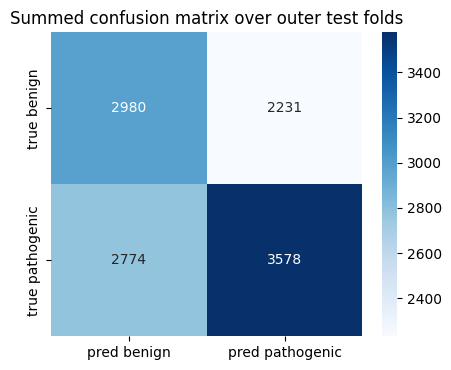

,threshold,precision,recall,accuracy,f1,tn,fp,fn,tp
fold,,,,,,,,,
0,0.725,0.598,0.063,0.652,0.114,1456,35,770,52
1,0.419,0.420,1.000,0.420,0.591,0,1342,0,971
2,0.512,0.663,0.713,0.662,0.687,673,436,346,858
3,0.525,0.801,0.700,0.649,0.747,301,297,515,1199
4,0.614,0.805,0.303,0.453,0.441,550,121,1143,498


In [6]:
print(f"Threshold method: {THRESHOLD_METHOD}")
print(
    f"ROC-AUC     = {fold_metrics['roc_auc'].mean():.3f} ± {fold_metrics['roc_auc'].std():.3f}"
)
print(
    f"Precision   = {fold_metrics['precision'].mean():.3f} ± {fold_metrics['precision'].std():.3f}"
)
print(
    f"Recall      = {fold_metrics['recall'].mean():.3f} ± {fold_metrics['recall'].std():.3f}"
)
print(
    f"Accuracy    = {fold_metrics['accuracy'].mean():.3f} ± {fold_metrics['accuracy'].std():.3f}"
)
print(
    f"F1          = {fold_metrics['f1'].mean():.3f} ± {fold_metrics['f1'].std():.3f}"
)
print(
    f"Threshold   = {fold_metrics['threshold'].mean():.3f} ± {fold_metrics['threshold'].std():.3f}"
)

display(cls_summary.round(3))

cm = np.array(
    [
        [confusion_total["tn"], confusion_total["fp"]],
        [confusion_total["fn"], confusion_total["tp"]],
    ]
)
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred benign", "pred pathogenic"],
    yticklabels=["true benign", "true pathogenic"],
    ax=ax,
)
ax.set_title("Summed confusion matrix over outer test folds")
fig.tight_layout()
plt.show()

display(fold_metrics[["threshold", "precision", "recall", "accuracy", "f1", "tn", "fp", "fn", "tp"]].round(3))


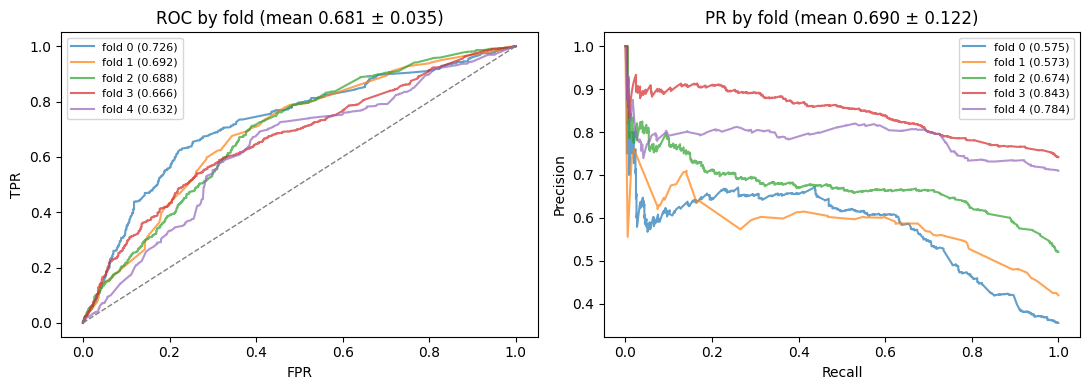

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

mean_roc = fold_metrics["roc_auc"].mean()
std_roc = fold_metrics["roc_auc"].std()
mean_pr = fold_metrics["pr_auc"].mean()
std_pr = fold_metrics["pr_auc"].std()

for fold, part in oof.groupby("fold"):
    fpr, tpr, _ = roc_curve(part["y_true"], part["y_proba"])
    axes[0].plot(
        fpr,
        tpr,
        alpha=0.7,
        label=f"fold {fold} ({roc_auc_score(part['y_true'], part['y_proba']):.3f})",
    )
    prec, rec, _ = precision_recall_curve(part["y_true"], part["y_proba"])
    axes[1].plot(
        rec,
        prec,
        alpha=0.7,
        label=f"fold {fold} ({average_precision_score(part['y_true'], part['y_proba']):.3f})",
    )

axes[0].plot([0, 1], [0, 1], ls="--", c="gray", lw=1)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title(f"ROC by fold (mean {mean_roc:.3f} ± {std_roc:.3f})")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"PR by fold (mean {mean_pr:.3f} ± {std_pr:.3f})")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


## Feature importance across folds

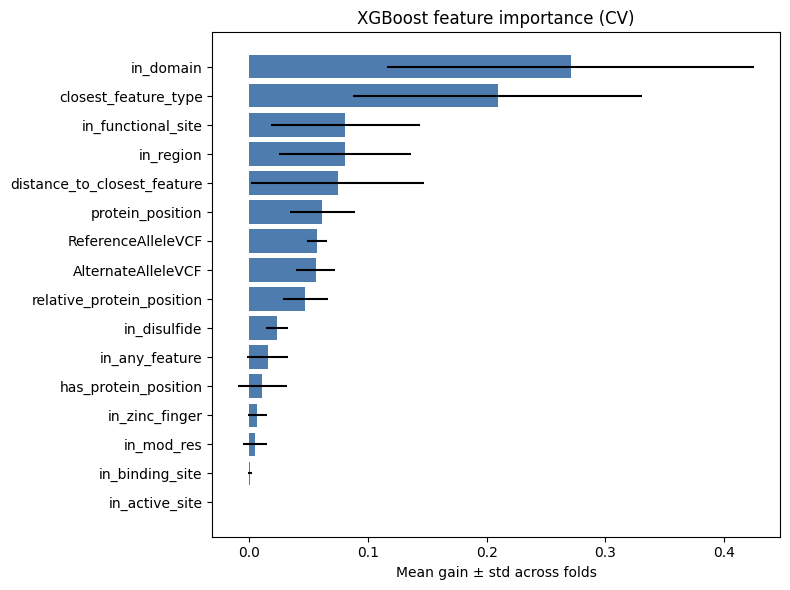

,mean,std
in_domain,0.2709,0.1545
closest_feature_type,0.2093,0.1217
in_functional_site,0.0810,0.0624
in_region,0.0805,0.0559
distance_to_closest_feature,0.0744,0.0731
protein_position,0.0615,0.0272
ReferenceAlleleVCF,0.0567,0.0084
AlternateAlleleVCF,0.0561,0.0165
relative_protein_position,0.0473,0.0191
in_disulfide,0.0233,0.0096


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    importance_df.index[::-1],
    importance_df["mean"].iloc[::-1],
    xerr=importance_df["std"].iloc[::-1],
    color="#3b6ea5",
    alpha=0.9,
)
ax.set_xlabel("Mean gain ± std across folds")
ax.set_title("XGBoost feature importance (CV)")
fig.tight_layout()
plt.show()

importance_df[["mean", "std"]].round(4)


## Persist fold predictions

Per-fold test predictions are still saved for inspection; headline metrics are mean±std,
not pooled OOF ROC.


In [9]:
oof_path = MODELS_DIR / "xgb_cv_oof_predictions.parquet"
metrics_path = MODELS_DIR / "xgb_cv_fold_metrics.csv"
tuning_path = MODELS_DIR / "xgb_cv_tuning_log.csv"
oof.to_parquet(oof_path, index=False)
fold_metrics.to_csv(metrics_path)
tuning_log.to_csv(tuning_path, index=False)
print("Saved", oof_path)
print("Saved", metrics_path)
print("Saved", tuning_path)
fold_metrics.round(3)


Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/xgb_cv_oof_predictions.parquet
Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/xgb_cv_fold_metrics.csv
Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/xgb_cv_tuning_log.csv


,n_train,n_test,n_test_genes,best_inner_roc_auc,n_estimators,threshold,roc_auc,pr_auc,accuracy,precision,...,tn,fp,fn,tp,param_subsample,param_reg_lambda,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree
fold,,,,,,,,,,,,,,,,,,,,,
0,9250,2313,19,0.660,90,0.725,0.726,0.575,0.652,0.598,...,1456,35,770,52,0.8,5.0,5,5,0.03,0.7
1,9250,2313,26,0.636,2,0.419,0.692,0.573,0.420,0.420,...,0,1342,0,971,0.8,1.0,1,5,0.03,0.8
2,9250,2313,31,0.633,37,0.512,0.688,0.674,0.662,0.663,...,673,436,346,858,0.9,1.0,1,6,0.10,0.8
3,9251,2312,30,0.670,51,0.525,0.666,0.843,0.649,0.801,...,301,297,515,1199,0.9,5.0,10,5,0.10,0.8
4,9251,2312,31,0.657,14,0.614,0.632,0.784,0.453,0.805,...,550,121,1143,498,0.9,5.0,5,3,0.10,0.7


- Gene-proxy features dropped; remaining UniProt/allele signal is weak but above chance within folds.
- Fold composition (mega-genes, label-rate skew) still drives PR-AUC swings.
- Next: mega-gene weighting; stronger features (conservation, AF, AlphaMissense, embeddings).
